# Tema : Modelos de suavización exponencial
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

# Librerías necesarias

In [1]:
# Datos
library(tidyverse)
library(wbstats)

# Modelos de tiempo
library(fable)       # Modelos ETS, ARIMA, etc. (reemplaza forecast)
library(feasts)      # Descomposición de series de tiempo
library(ggtime)      # Visualización
library(tsibble)     # Estructura de datos para series de tiempo

# tamaño de los graficos
options(repr.plot.width = 8, 
        repr.plot.height = 6,
        repr.plot.res = 300,
        repr.plot.pointsize = 14)

set_theme(theme_bw())

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: fabletools

Attaching package: ‘tsibble’

The following object is masked from ‘package:lubridate’:

    interval

The following objects are masked from ‘package:base’:

    intersect, setdiff, union



---

## Modelo SES

$$
\begin{align*}
\text{Ecuación de pronóstico} && \hat{y}_{t+h|t} = \ell_{t} \\
\text{Ecuación de suavizado} && \ell_{t} = \alpha y_{t} + (1 - \alpha)\ell_{t-1}
\end{align*}
$$

- Trend (None): El modelo asume que el PIB no tiene una tendencia alcista o bajista constante en el tiempo. Por eso, el pronóstico futuro será una línea recta horizontal.
- Seasonal (None): No se detectaron ni aplicaron patrones que se repitan (como ciclos anuales).

### Ejercicio 1. Pronóstico del crecimiento PIB de Colombia

Usando los datos del Banco Mundial, estimar la Suavizamiento Exponencial Simple como función de pronóstico del crecimiento anual del PIB de Colombia. 1960-2024. Finalmente, realice el pronóstico del PIB de Colombia para los próximos 5 años.

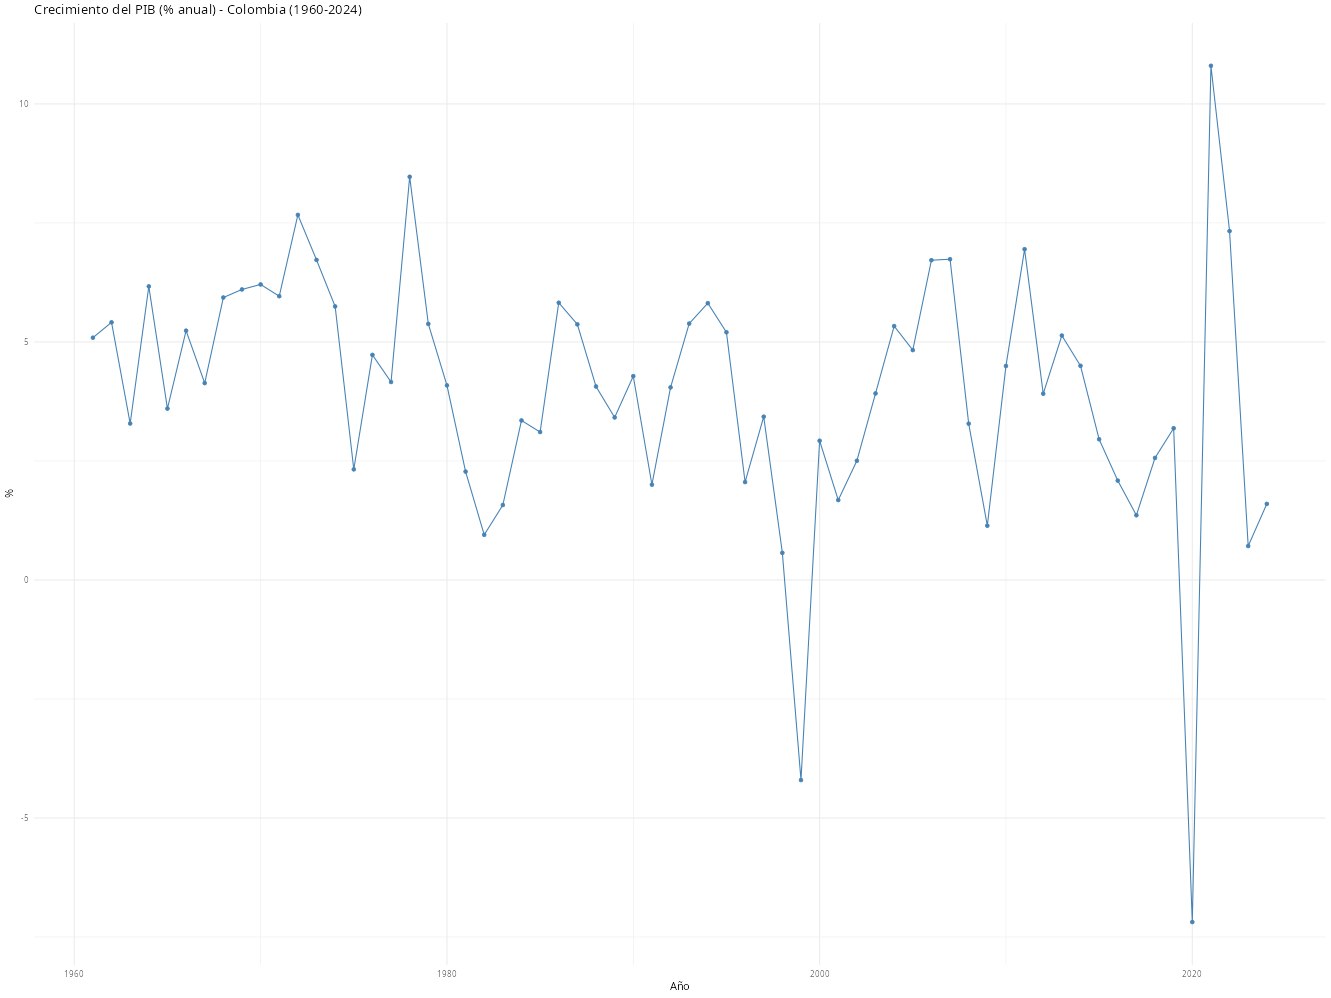

In [2]:
# Descargar los datos del Banco Mundial
data_wb <- wb_data(indicator = "NY.GDP.MKTP.KD.ZG", country = "COL",
                   start_date = 1960, end_date = 2024)

pib_col <- data_wb |>
  select(year = date, pib = NY.GDP.MKTP.KD.ZG) |>
  drop_na(pib) |>
  as_tsibble(index = year)

# Gráfico de la serie
pib_col |>
  autoplot(pib, colour = "steelblue") +
  geom_point(colour = "steelblue") +
  labs(
    title = "Crecimiento del PIB (% anual) - Colombia (1960-2024)",
    x = "Año", y = "%"
  ) +
  theme_minimal()

In [3]:
# Modelo SES: error aditivo, sin tendencia, sin estacionalidad
modelo_ses <- pib_col |>
  model(SES = ETS(pib ~ error("A") + trend("N") + season("N")))

report(modelo_ses)

Series: pib 
Model: ETS(A,N,N) 
  Smoothing parameters:
    alpha = 0.05784068 

  Initial states:
     l[0]
 4.662438

  sigma^2:  7.3408

     AIC     AICc      BIC 
397.7170 398.1170 404.1936 


$$
\begin{align*}
\text{Ecuación de pronóstico} && \hat{y}_{t+h|t} = \ell_{t} \\
\text{Ecuación de suavizado} && \ell_{t} = 0.0517261 y_{t} + (1 - 0.0517261)\ell_{t-1} \\
\text{Valor inicial} && \ell_{0} = 4.5991175
\end{align*}
$$

**Interpretación**

- El modelo le asigna solo un 5.17% de peso al dato más reciente (el último año observado) y un 94.83% de peso a la historia previa (el nivel suavizado anterior).
- El valor $\alpha$ al ser un valor muy cercano a 0, el modelo es muy conservador e ignora las fluctuaciones de corto plazo y prefiere mantener un promedio estable de largo plazo ($\ell_{0}$).

Plot variable not specified, automatically selected `.vars = .fitted`


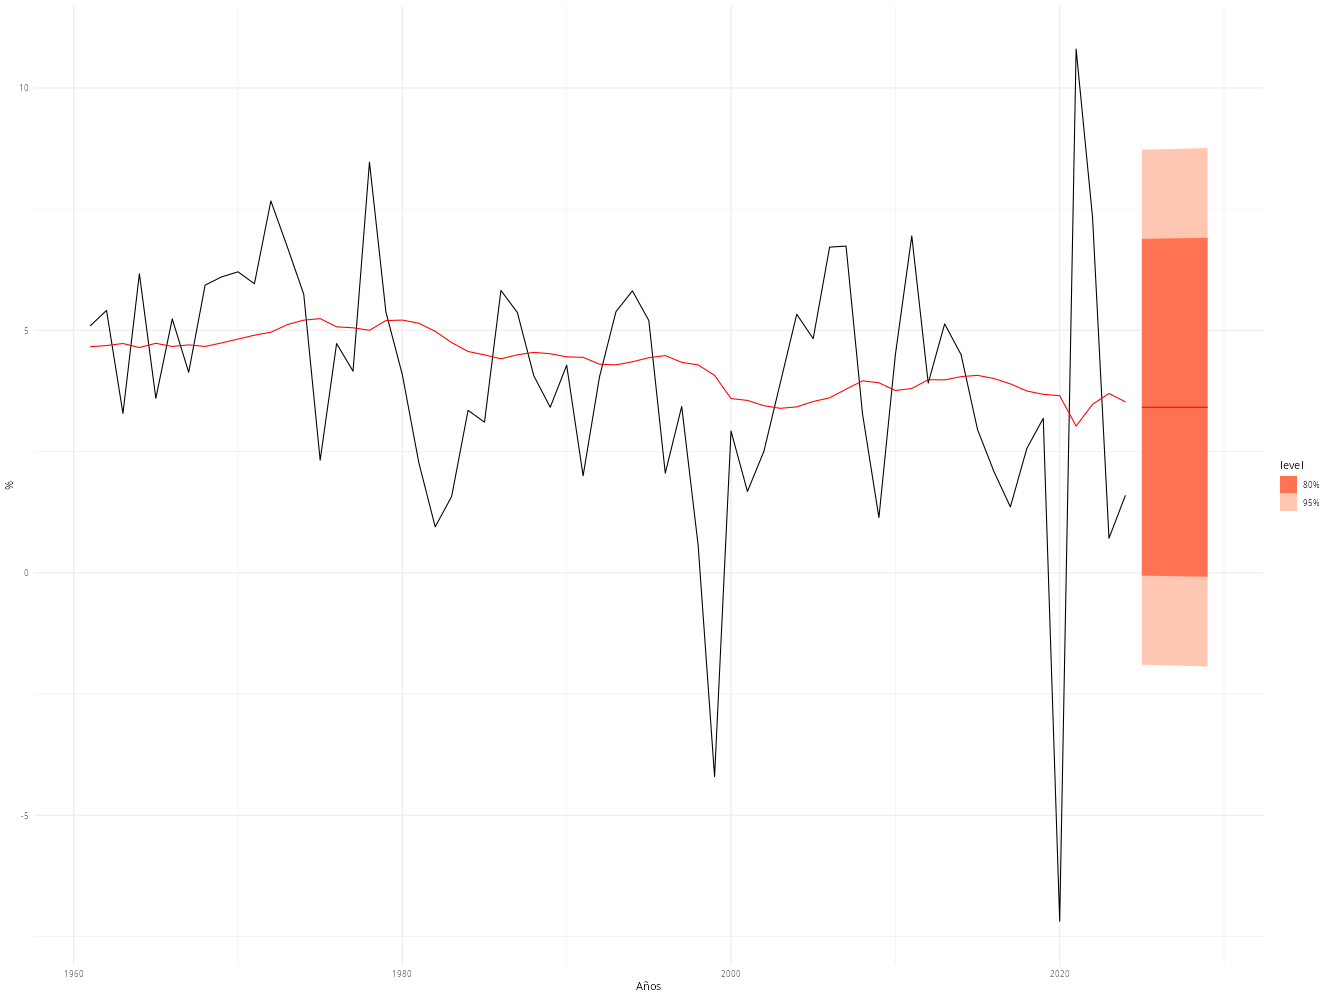

In [4]:
# Pronóstico de los próximos 5 años
t_pronostico <- 5

pronostico_ses <- modelo_ses |>
  forecast(h = t_pronostico)

# Gráfico de resultados del pronóstico
pronostico_ses |>
  autoplot(pib_col, colour = "red", linetype = "dashed") +
  autolayer(fitted(modelo_ses), colour = "red") +
  labs(x = "Años", y = "%") +
  theme_minimal()

---

## Modelo Holt con tendencia constante y amortiguada

**Holt tendencia**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} = \ell_{t} + hb_{t} \\
  \text{Ecuación nivel}   && \ell_{t} = \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t}    = \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)b_{t-1}
\end{align*}
$$

**Holt tendencia amortiguada**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + (\phi+\phi^2 + \dots + \phi^{h})b_{t} \\
  \text{Ecuación nivel}   && \ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + \phi b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)\phi b_{t-1}
\end{align*}
$$

### Ejercicio 2. Pronóstico del PIB de Colombia considerando tendencia

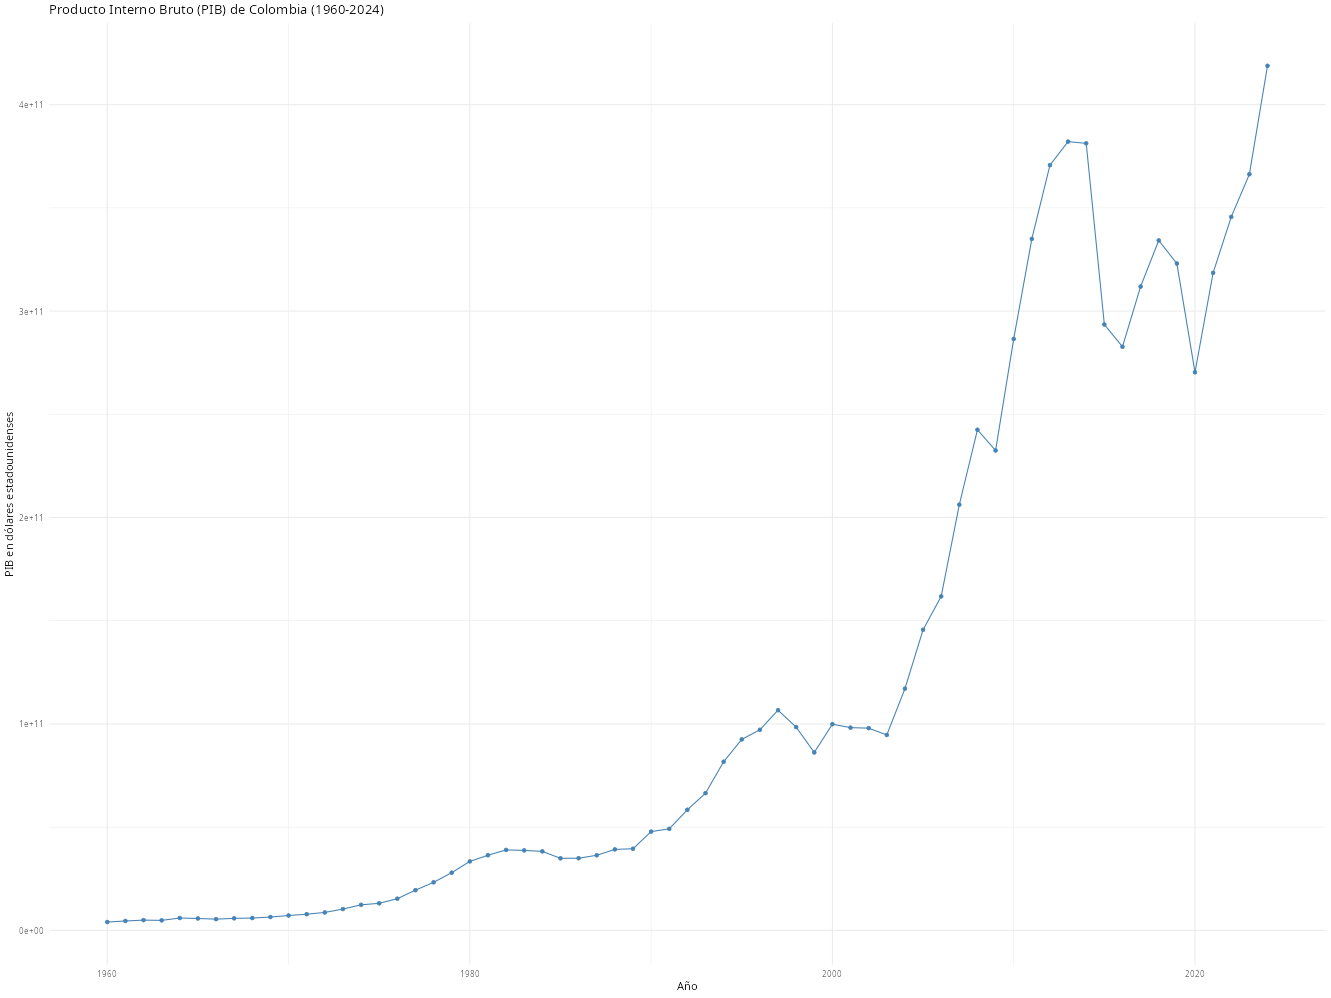

In [5]:
# Descargar datos del PIB nominal de Colombia
data_wb2 <- wb_data(indicator = "NY.GDP.MKTP.CD", country = "COL",
                    start_date = 1960, end_date = 2024)

pib_col2 <- data_wb2 |>
  select(year = date, pib = NY.GDP.MKTP.CD) |>
  drop_na(pib) |>
  as_tsibble(index = year)

# Gráfico de la serie
pib_col2 |>
  autoplot(pib, colour = "steelblue") +
  geom_point(colour = "steelblue") +
  labs(
    title = "Producto Interno Bruto (PIB) de Colombia (1960-2024)",
    x = "Año", y = "PIB en dólares estadounidenses"
  ) +
  theme_minimal()

In [6]:
# Modelo Holt y Holt con tendencia amortiguada
modelos_holt <- pib_col2 |>
  model(
    Holt               = ETS(pib ~ error("A") + trend("A") + season("N")),
    Holt_amortiguada   = ETS(pib ~ error("A") + trend("Ad") + season("N"))
  )

# Imprimir modelo Holt con tendencia
cat("Modelo de Holt con tendencia\n")
modelos_holt |> select(Holt) |> report()

Modelo de Holt con tendencia
Series: pib 
Model: ETS(A,A,N) 
  Smoothing parameters:
    alpha = 0.9998998 
    beta  = 0.04934068 

  Initial states:
       l[0]      b[0]
 4122080397 640221002

  sigma^2:  4.749507e+20

     AIC     AICc      BIC 
3371.840 3372.857 3382.712 


**Interpretación**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} = \ell_{t} + hb_{t} \\
  \text{Ecuación nivel}   && \ell_{t} = 1.0000000 y_{t} + (1 - 1.0000000)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t}    = 0^*(\ell_{t} - \ell_{t-1}) + (1 -0^*)b_{t-1} \\
  \text{Valor inicial} && \ell_{0} = 3.6556e+09 && b_{0} = 5.6533e+09
\end{align*}
$$

- Es modelo estima $\alpha$ con valor máximo posible indicando que le da un peso del 100% a la observación más reciente y olvida por completo el nivel calculado anteriormente. A su vez, $b = 0$ con el valor mínimo posible indica que modelo no actualiza la pendiente con los datos nuevos.
- De forma conjunta el modelo se comporta como una caminata aleatora. Solo depende del valor anterior y los valores iniciales tanto de la serie como de la tendencia se mantienen están presentes en todo momento.

In [7]:
# Imprimir modelo Holt con tendencia amortiguada
cat("Modelo de Holt con tendencia amortiguada\n")
modelos_holt |> select(Holt_amortiguada) |> report()

Modelo de Holt con tendencia amortiguada
Series: pib 
Model: ETS(A,Ad,N) 
  Smoothing parameters:
    alpha = 0.9998994 
    beta  = 0.2973219 
    phi   = 0.8000016 

  Initial states:
       l[0]      b[0]
 4122080396 640221003

  sigma^2:  4.797949e+20

     AIC     AICc      BIC 
3373.425 3374.874 3386.472 


**Interpretación**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + (0.9950000 + 0.9950000^2 + \dots + 0.9950000^{h})b_{t} \\
  \text{Ecuación nivel}   && \ell_{t} &= 1.0000000 y_{t} + (1 - 1.0000000)(\ell_{t-1} + 0.9950000 b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t} &= 0.0408419^*(\ell_{t} - \ell_{t-1}) + (1 -0.0408419^*)0.9950000 b_{t-1} \\
  \text{Valor inicial} && \ell_{0} = 4.0678e+09 && b_{0} = 1.0495e+09
\end{align*}
$$

- Similar a los resultados del modelo anterior. Sin embargo tenemos al nuevo parámetro $\phi = 0.9950000$ indicando que la tendencia se irá amortiguando o debilitando lentamente con el tiempo. Esto genera pronósticos más conservadores.

Plot variable not specified, automatically selected `.vars = .fitted`


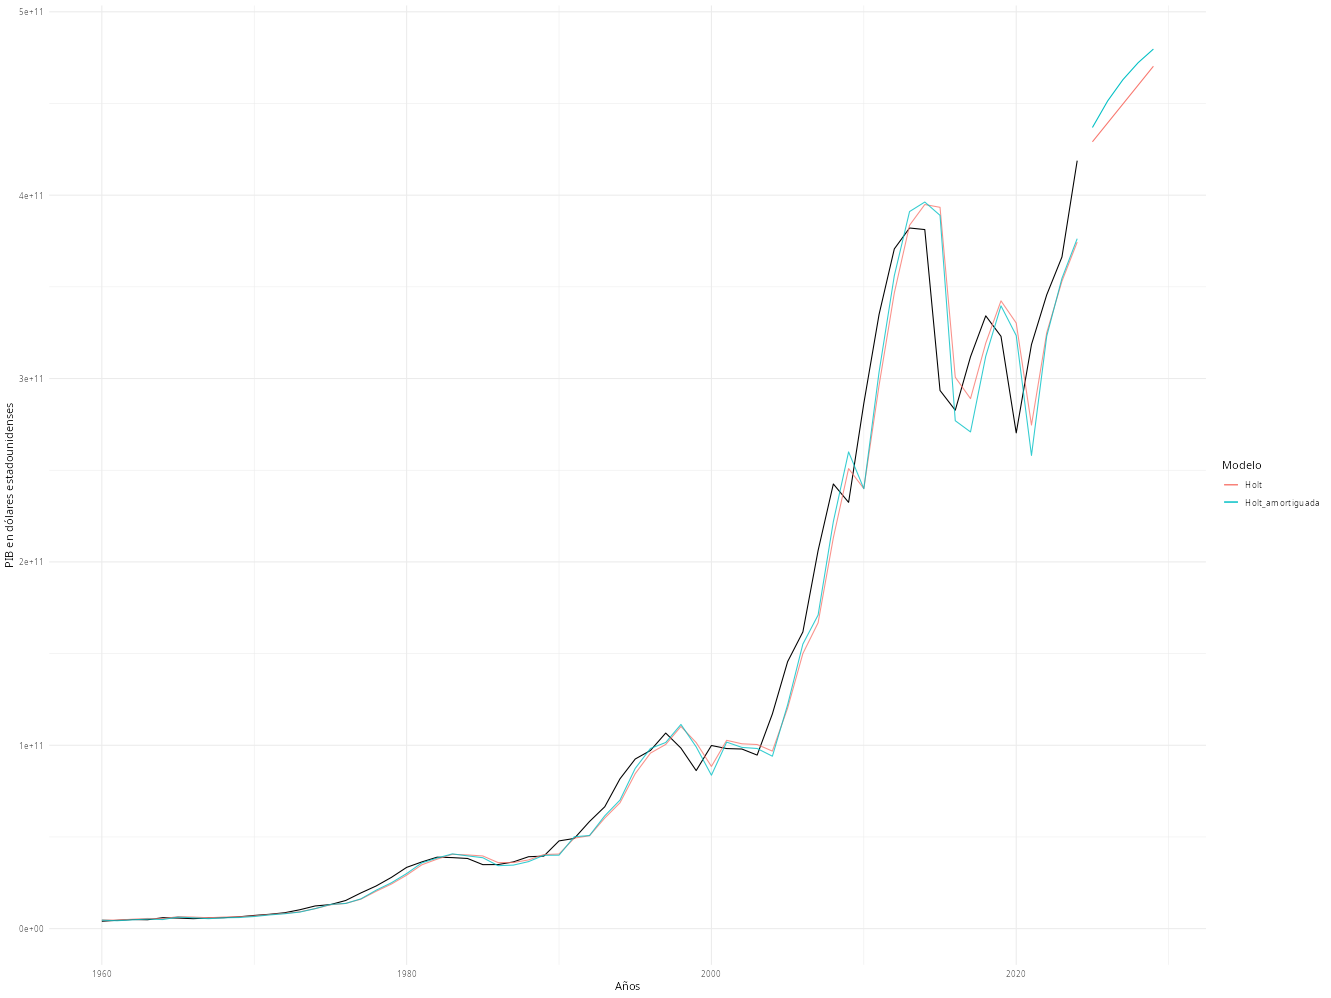

In [8]:
# Pronóstico de los próximos 5 años
t_pronostico <- 5

pronostico_holt <- modelos_holt |>
  forecast(h = t_pronostico)

# Gráfico de resultados del pronóstico
pronostico_holt |>
  autoplot(pib_col2, level = NULL) +
  autolayer(fitted(modelos_holt), alpha = 0.8) +
  labs(x = "Años", y = "PIB en dólares estadounidenses", colour = "Modelo") +
  theme_minimal()

---

## Holt-Winters estacionalidad

**Método aditivo**
$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} + s_{t+h-m(k+1)} \\
  \text{Ecuación nivel}&& \ell_{t} &= \alpha(y_{t} - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}&& b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}\\
  \text{Ecuación estacional}&& s_{t} &= \gamma (y_{t}-\ell_{t-1}-b_{t-1}) + (1-\gamma)s_{t-m},
\end{align*}
$$

**Método multiplicativo**
$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= (\ell_{t} + hb_{t})s_{t+h-m(k+1)} \\
  \text{Ecuación nivel}&& \ell_{t} &= \alpha \frac{y_{t}}{s_{t-m}} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}&& b_{t} &= \beta^*(\ell_{t}-\ell_{t-1}) + (1 - \beta^*)b_{t-1}                \\
  \text{Ecuación estacional}&& s_{t} &= \gamma \frac{y_{t}}{(\ell_{t-1} + b_{t-1})} + (1 - \gamma)s_{t-m}.
\end{align*}
$$

### Ejemplo 3. Empleo mensual en el sector de ocio y hostelería en EE. UU

Describir la modelización ETS estacional utilizando datos mensuales de empleo en Estados Unidos para los trabajos de ocio y hospitalidad desde enero de 2001 hasta septiembre de 2019.

Rows: 143412 Columns: 3
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): unique_id
dbl  (1): y
date (1): ds

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


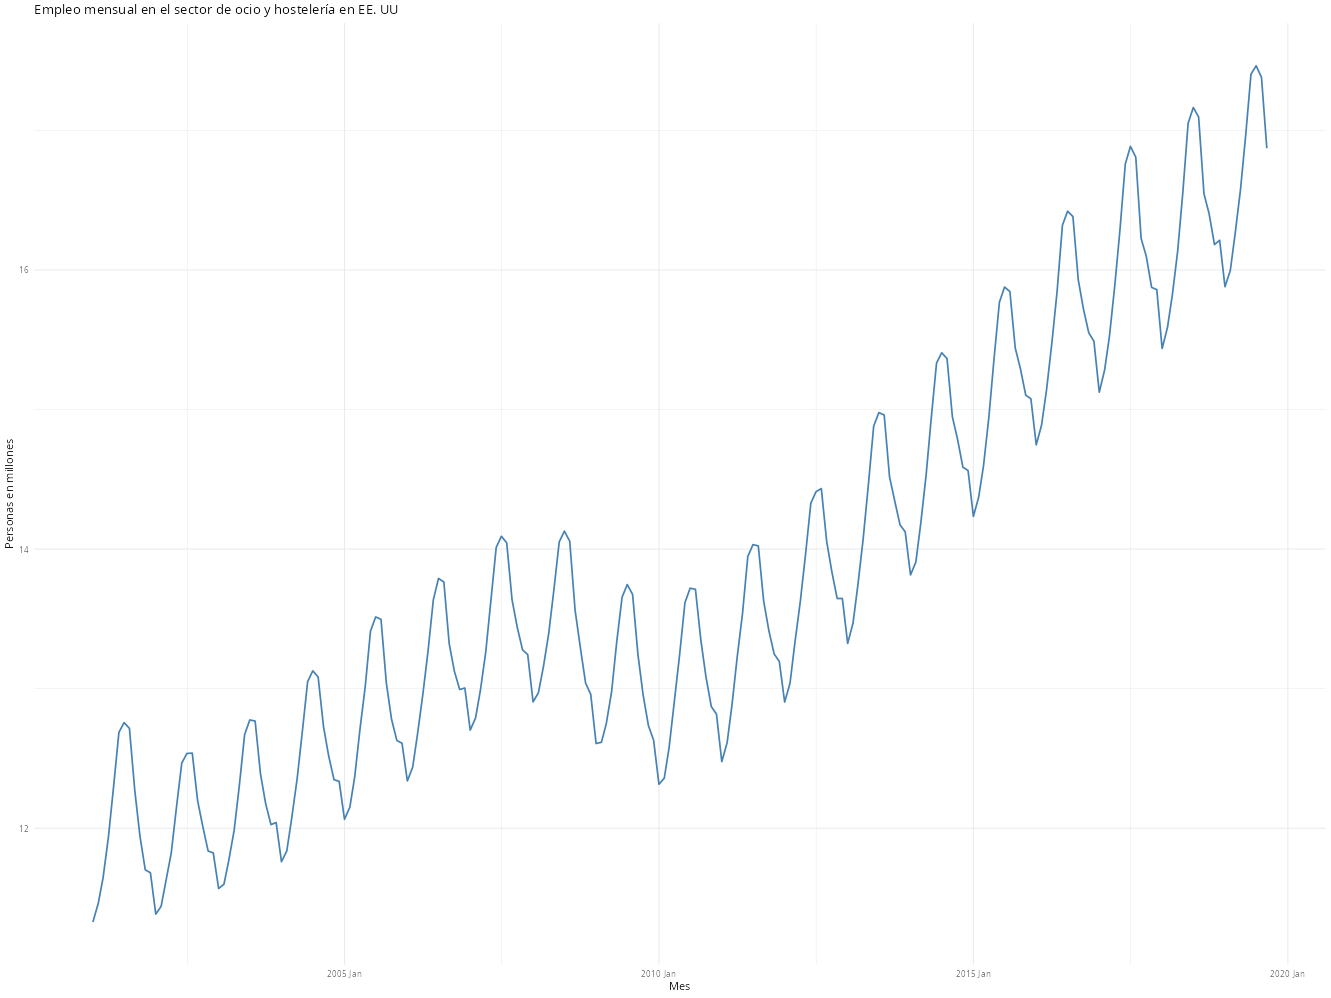

In [9]:
# Leer y ajustar datos
github_data <- "https://raw.githubusercontent.com/fersalme/series-tiempo-econometria/refs/heads/main/data/us_employment.csv"

serie_us_employment <- read_csv(github_data) |>
  filter(ds >= "2001-01-01", unique_id == "Leisure and Hospitality") |>
  mutate(
    ds = yearmonth(ds),
    y  = y / 1e3
  ) |>
  as_tsibble(index = ds)

# Gráfico de la serie
serie_us_employment |>
  autoplot(y, colour = "steelblue", linewidth = 0.8) +
  labs(
    title = "Empleo mensual en el sector de ocio y hostelería en EE. UU",
    x = "Mes", y = "Personas en millones"
  ) +
  theme_minimal()

In [10]:
# Modelos Holt-Winters aditivo y multiplicativo, con y sin tendencia amortiguada
modelos_holt_winter <- serie_us_employment |>
  model(
    `Holt-Winters`                                      = ETS(y ~ error("A") + trend("A")  + season("A")),
    `Holt-Winters tendencia amortiguada`                = ETS(y ~ error("A") + trend("Ad") + season("A")),
    `Holt-Winters multiplicativo`                       = ETS(y ~ error("A") + trend("A")  + season("M")),
    `Holt-Winters multiplicativo tendencia amortiguada` = ETS(y ~ error("A") + trend("Ad") + season("M"))
  )

# Comparar por AIC — menor AIC
glance(modelos_holt_winter) |>
  select(.model, AIC) |>
  arrange(AIC)

# A tibble: 4 × 2
  .model                                              AIC
  <chr>                                             <dbl>
1 Holt-Winters multiplicativo tendencia amortiguada -227.
2 Holt-Winters tendencia amortiguada                -161.
3 Holt-Winters                                      -159.
4 Holt-Winters multiplicativo                        108.

In [11]:
# Imprimir mejor modelo
cat("Modelo método de Holt-Winters multiplicativo con tendencia amortiguada\n")
modelos_holt_winter |>
  select(`Holt-Winters multiplicativo tendencia amortiguada`) |>
  report()

Modelo método de Holt-Winters multiplicativo con tendencia amortiguada
Series: y 
Model: ETS(A,Ad,M) 
  Smoothing parameters:
    alpha = 0.9751777 
    beta  = 0.08898011 
    gamma = 0.02404377 
    phi   = 0.9678061 

  Initial states:
     l[0]       b[0]     s[0]    s[-1]     s[-2]    s[-3]    s[-4]    s[-5]    s[-6]    s[-7]     s[-8]     s[-9]    s[-10]
 11.88231 0.05609152 0.976608 0.980612 0.9955662 1.012379 1.044096 1.048953 1.044625 1.017985 0.9940962 0.9737921 0.9586874
    s[-11]
 0.9525996

  sigma^2:  0.0015

      AIC      AICc       BIC 
-226.8949 -223.5745 -165.4051 


$$
\begin{align*}
  \hat{y}_{t+h|t} &= \left[\ell_{t} + (0.9654+0.9654^2 + \dots + 0.9654^{h})b_{t}\right]s_{t+h-12(k+1)} \\
  \ell_{t} &= 1.0(y_{t} / s_{t-12}) + (1 - 1.0)(\ell_{t-1} + 0.9654 b_{t-1})\\
  b_{t} &= 0.1775(\ell_{t} - \ell_{t-1}) + (1 - 0.1775)0.9654 b_{t-1}             \\
  s_{t} &= 1.4857e{-08} \frac{y_{t}}{(\ell_{t-1} + 0.9654 b_{t-1})} + (1 - 1.4857e{-08})s_{t-12}.
\end{align*}
$$

**Interpretación**

- Al ser Multiplicativo, el modelo asume que la estacionalidad varía en proporción al nivel de la serie, es decir, los "picos" se hacen más grandes si el valor de la serie aumenta.
- Parámetro de suavizamiento de nivel ($\alpha : 1.0000000$): El actual de la serie depende del valor anterior.
- Parámetro de suavizamiento de tendencia ($\beta: 0.1774632$): El modelo cambia su estimación de la pendiente de forma pausada.
- Parámetro de suavizamiento de estacional ($\gamma \sim 0$): El patrón estacional es estático por lo que el comportamiento se repite exactamente igual año tras año y no necesita actualizarse con la información nueva.
- Tendencia amortiguada ($\phi : 0.9653$): Evita que la serie crezca hasta el infinito sino que crece pero cada vez menos (~3% menos).
- Componente estacional multiplicativo (s.0 a s.11): Indica que en momentos de temporada alta como en el mes de mayo (initial_seasons.5) la serie es un 2.7% más alta que el comportamiento promedio y en momentos bajos como enero (initial_seasons.0) la serie está un 6.3% por debajo.

Plot variable not specified, automatically selected `.vars = .fitted`


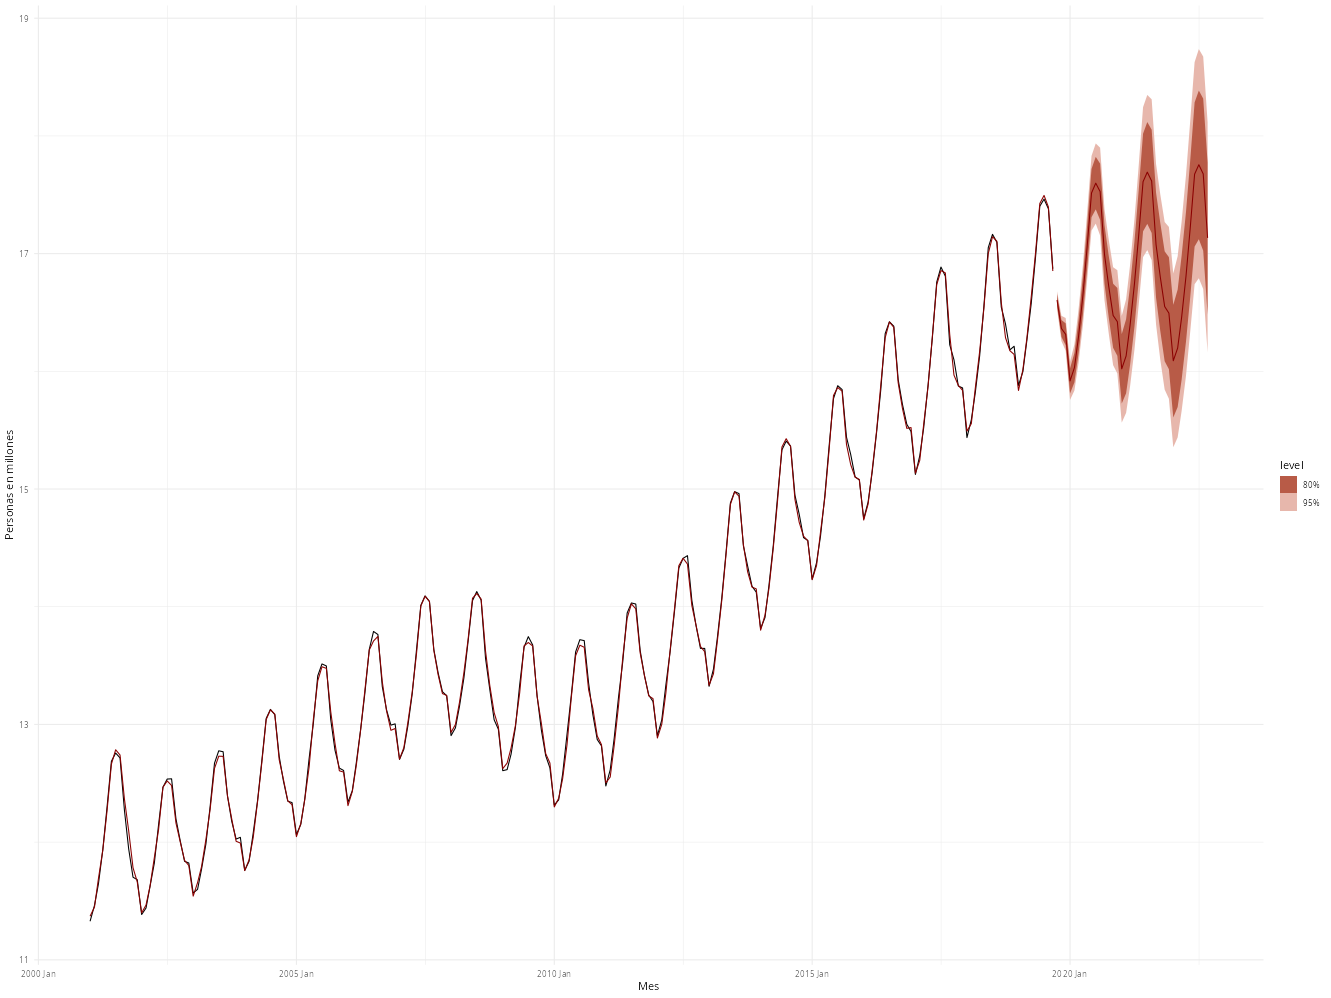

Ignoring unknown labels:
• colour : "Modelo"

In [12]:
# Pronóstico de los próximos 3 años = 12 meses * 3 años = 36 períodos
t_pronostico <- 36

pronostico_hw_mult <- modelos_holt_winter |>
  select(`Holt-Winters multiplicativo tendencia amortiguada`) |>
  forecast(h = t_pronostico)

# Gráfico de resultados del pronóstico
pronostico_hw_mult |>
  autoplot(serie_us_employment, colour = "darkred", linetype = "dashed") +
  autolayer(
    fitted(modelos_holt_winter |> select(`Holt-Winters multiplicativo tendencia amortiguada`)),
    colour = "darkred"
  ) +
  labs(
    x = "Mes", y = "Personas en millones",
    colour = "Modelo"
  ) +
  theme_minimal()

---

## Modelo ETS — Modelos de espacio de estados con innovaciones para el suavizamiento exponencial

- Un modelo ETS se especifica mediante un tipo de error (E; aditivo o multiplicativo), un tipo de tendencia (T; aditiva o multiplicativa, ambas amortiguadas o no amortiguadas, o ninguna) y un tipo de estacionalidad (S; aditiva, multiplicativa o ninguna).

$$
ETS(Error = \{A,M\}, Tendencia =\{N,A,Ad\}, Estacional = \{N,A,M\})
$$

- Aditivo

$$
y_t = \hat{y}_{t|t-1} + e_t
$$

- Multiplicativo

$$
y_t = \hat{y}_{t|t-1}\cdot (1 + e_t)
$$

### Ejemplo 4. Pronóstico de la Tasa de desempleo en Colombia

Rows: 301 Columns: 3
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ";"
dbl  (2): Tasa de desempleo - total nacional, Tasa de ocupación - total nacional
date (1): Periodo(MMM, AAAA)

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


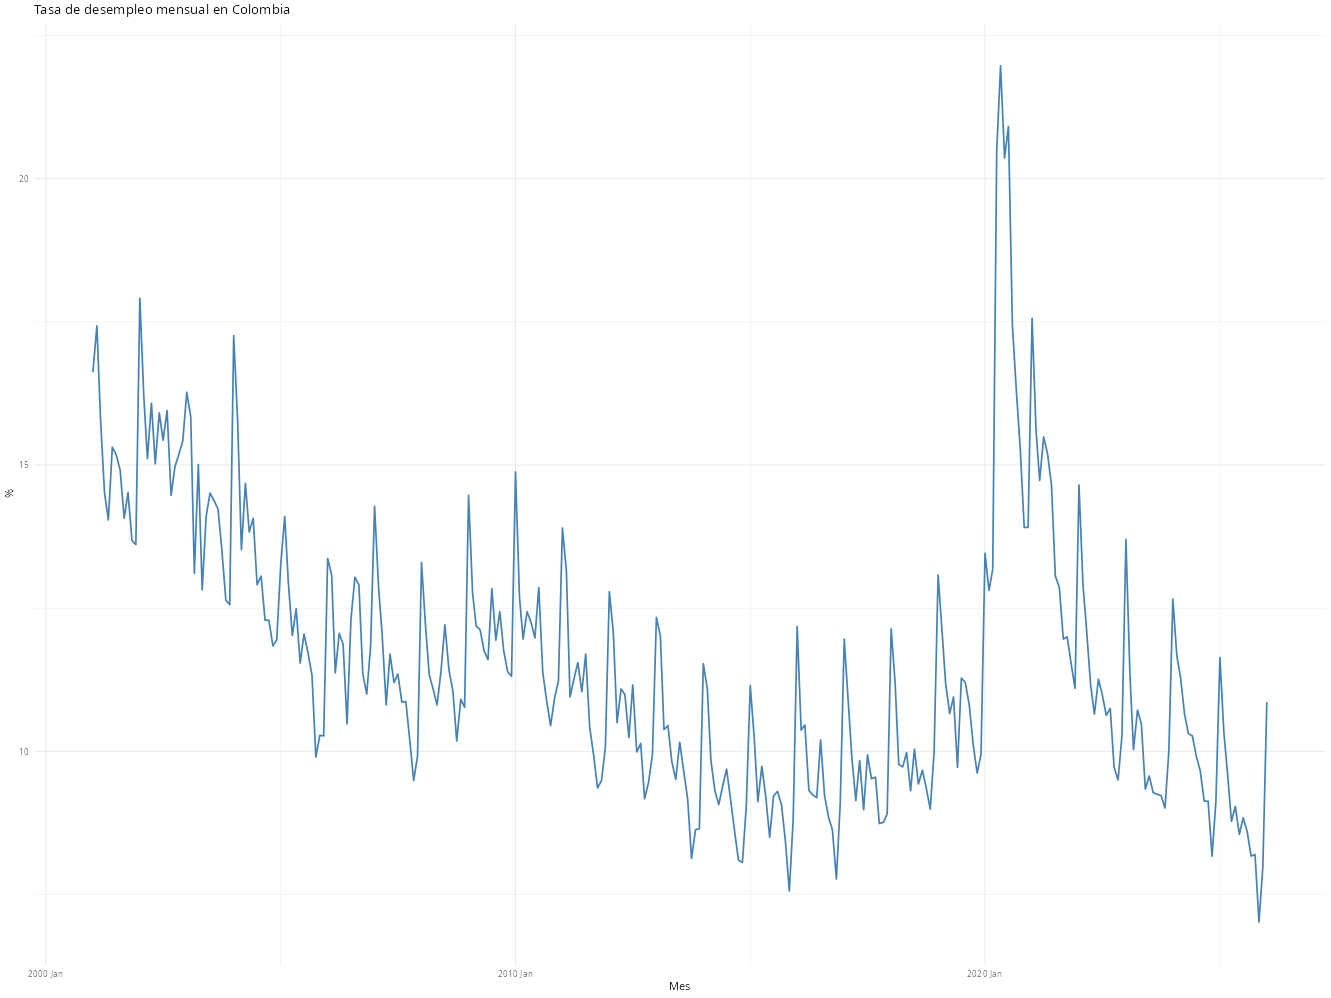

In [14]:
# Datos
github_data <- "https://raw.githubusercontent.com/fersalme/series-tiempo-econometria/refs/heads/main/data/Mercado%20laboral%20y%20poblaci%C3%B3n.csv"

serie_tasa_desempleo_co <- read_delim(github_data, delim = ";", locale = locale(decimal_mark = ",")) |>
  rename(
    fecha          = `Periodo(MMM, AAAA)`,
    tasa_desempleo = `Tasa de desempleo - total nacional`,
    tasa_ocupacion = `Tasa de ocupación - total nacional`
  ) |>
  mutate(fecha = yearmonth(fecha)) |>
  as_tsibble(index = fecha)

# Gráfico de la serie
serie_tasa_desempleo_co |>
  autoplot(tasa_desempleo, colour = "steelblue", linewidth = 0.8) +
  labs(
    title = "Tasa de desempleo mensual en Colombia",
    x = "Mes", y = "%"
  ) +
  theme_minimal()

In [23]:
# Modelos ETS: combinación de error, tendencia y estacionalidad
# fable::ETS con especificación automática por combinaciones manuales
modelos_ETS <- serie_tasa_desempleo_co |>
  model(ETS(tasa_desempleo))

# Imprimir mejor modelo
report(modelos_ETS)


Series: tasa_desempleo 
Model: ETS(M,N,A) 
  Smoothing parameters:
    alpha = 0.8201543 
    gamma = 0.0001000544 

  Initial states:
     l[0]       s[0]     s[-1]     s[-2]      s[-3]      s[-4]     s[-5]       s[-6]     s[-7]     s[-8]     s[-9]  s[-10]
 15.68677 -0.9460487 -1.516991 -1.220617 -0.6082994 -0.1794744 0.4013079 -0.02527087 0.3183106 0.4750571 0.1471391 1.13997
   s[-11]
 2.014916

  sigma^2:  0.004

     AIC     AICc      BIC 
1538.291 1539.975 1593.897 


**Interpretación**

- Error multiplicativo (M): El modelo asume que la variabilidad residual no es constante. Si la tasa de desempleo sube, la incertidumbre también aumenta proporcionalmente. Esto se confirma con la prueba de Heterocedasticidad (H) de 1.83 (p-valor < 0.05), que indica que la varianza de los errores cambia en el tiempo.
- Sin tendencia (N): El modelo no detectó una dirección clara de crecimiento o decrecimiento persistente a largo plazo. Se comporta como un modelo que oscila alrededor de un nivel que cambia localmente.
- Estacionalidad aditiva (A): Los picos y valles mensuales se suman o restan de forma fija (en puntos porcentuales) al nivel, independientemente del nivel de desempleo.

Plot variable not specified, automatically selected `.vars = .fitted`


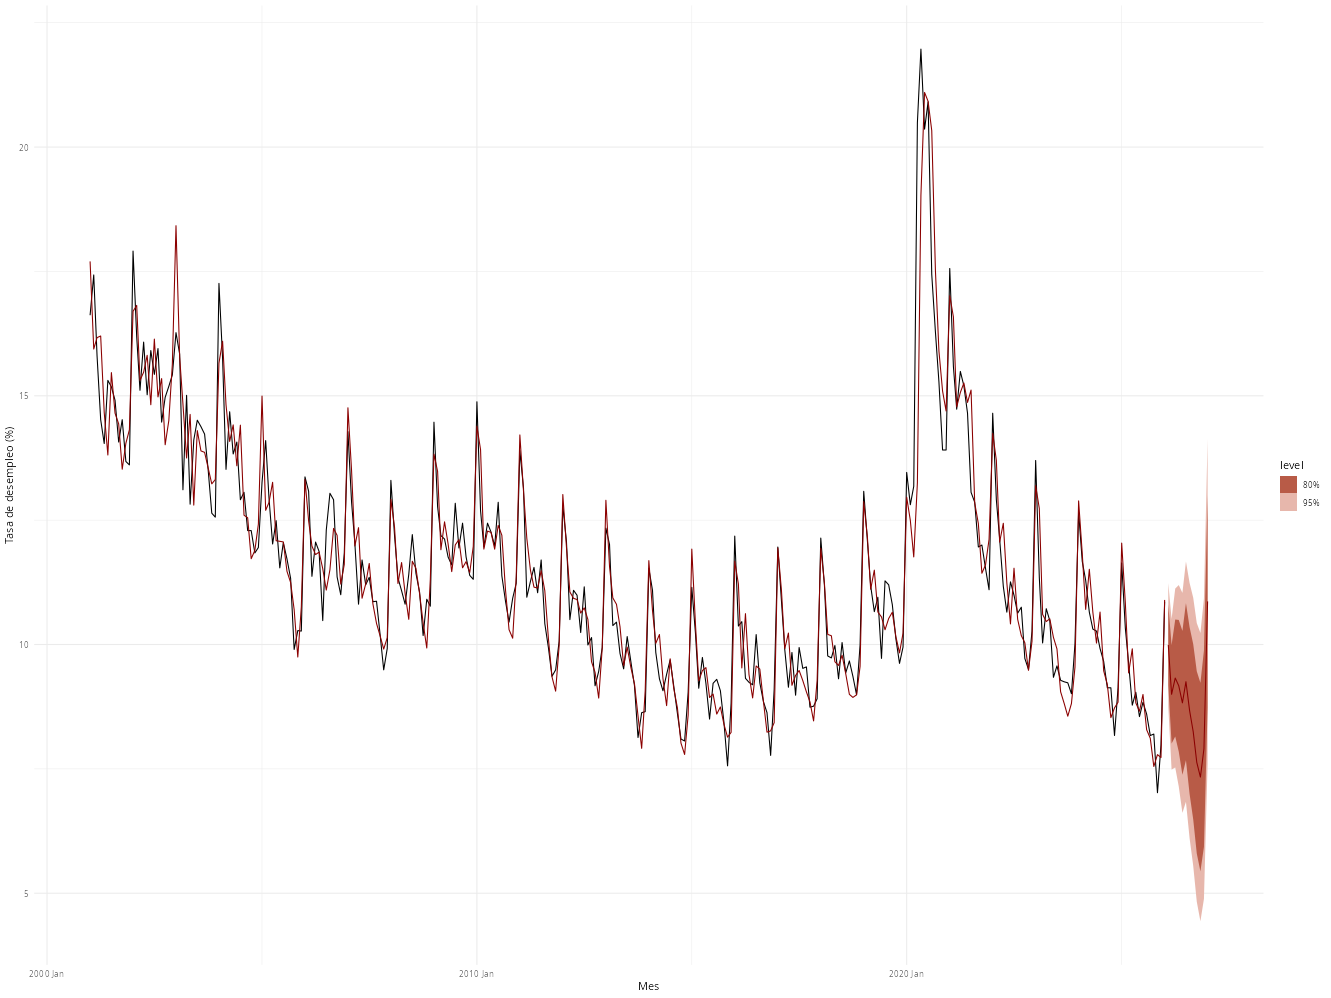

In [26]:
# Pronóstico de los próximos 12 meses
t_pronostico <- 12

pronostico_ETS <- modelos_ETS |>
  forecast(h = t_pronostico)

# Gráfico de resultados del pronóstico
pronostico_ETS |>
  autoplot(serie_tasa_desempleo_co, colour = "darkred", linetype = "dashed") +
  autolayer(fitted(modelos_ETS), colour = "darkred") +
  labs(x = "Mes", y = "Tasa de desempleo (%)") +
  theme_minimal()

---

## Regresión armónica dinámica (estacionalidad de largo plazo)

- Cuando existen períodos estacionales largos, a menudo implican múltiples patrones estacionales, por lo que es necesario utilizar un método que gestione este tipo de estacionalidad compleja.

- Si $m$ es el período estacional, entonces los primeros términos de Fourier vienen dados por:

$$
x_{1,t} = \sin\left(\textstyle\frac{2\pi t}{m}\right),
x_{2,t} = \cos\left(\textstyle\frac{2\pi t}{m}\right),
x_{3,t} = \sin\left(\textstyle\frac{4\pi t}{m}\right),
$$

Rows: 3288 Columns: 5
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): year, month, date, average, sd

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


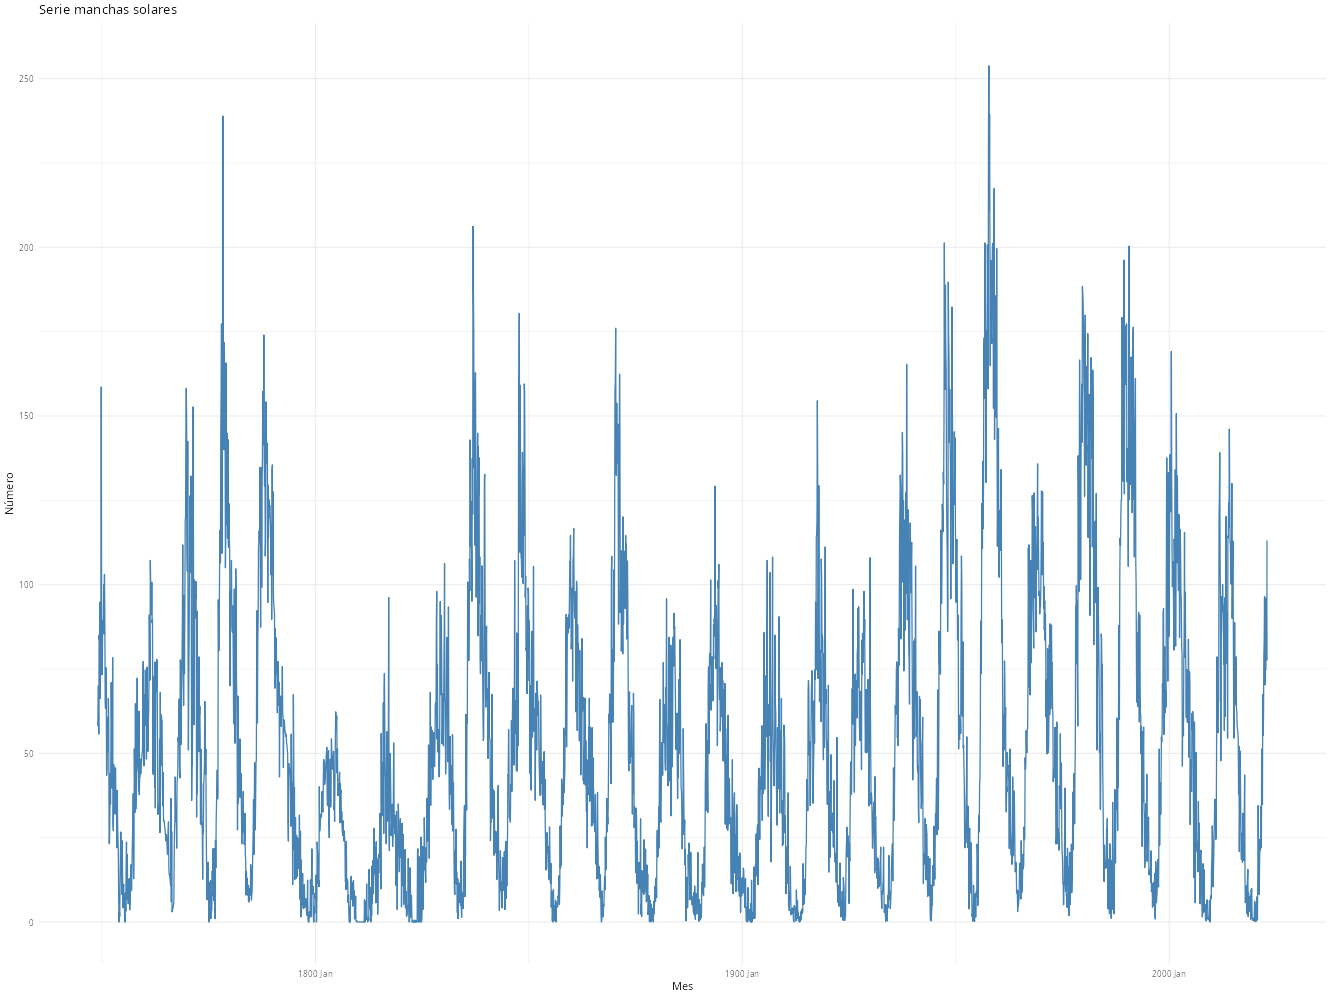

In [18]:
# Datos manchas solares
datos_sunspot <- "https://raw.githubusercontent.com/STAT-JET-ASU/Datasets/master/Instructor/sunspots.csv"

serie_sunspot <- read_csv(datos_sunspot) |>
  mutate(fecha = yearmonth(paste(year, month, sep = "-"))) |>
  as_tsibble(index = fecha)

# Gráfico de la serie completa
serie_sunspot |>
  autoplot(average, colour = "steelblue", linewidth = 0.6) +
  labs(
    title = "Serie manchas solares",
    x = "Mes", y = "Número"
  ) +
  theme_minimal()

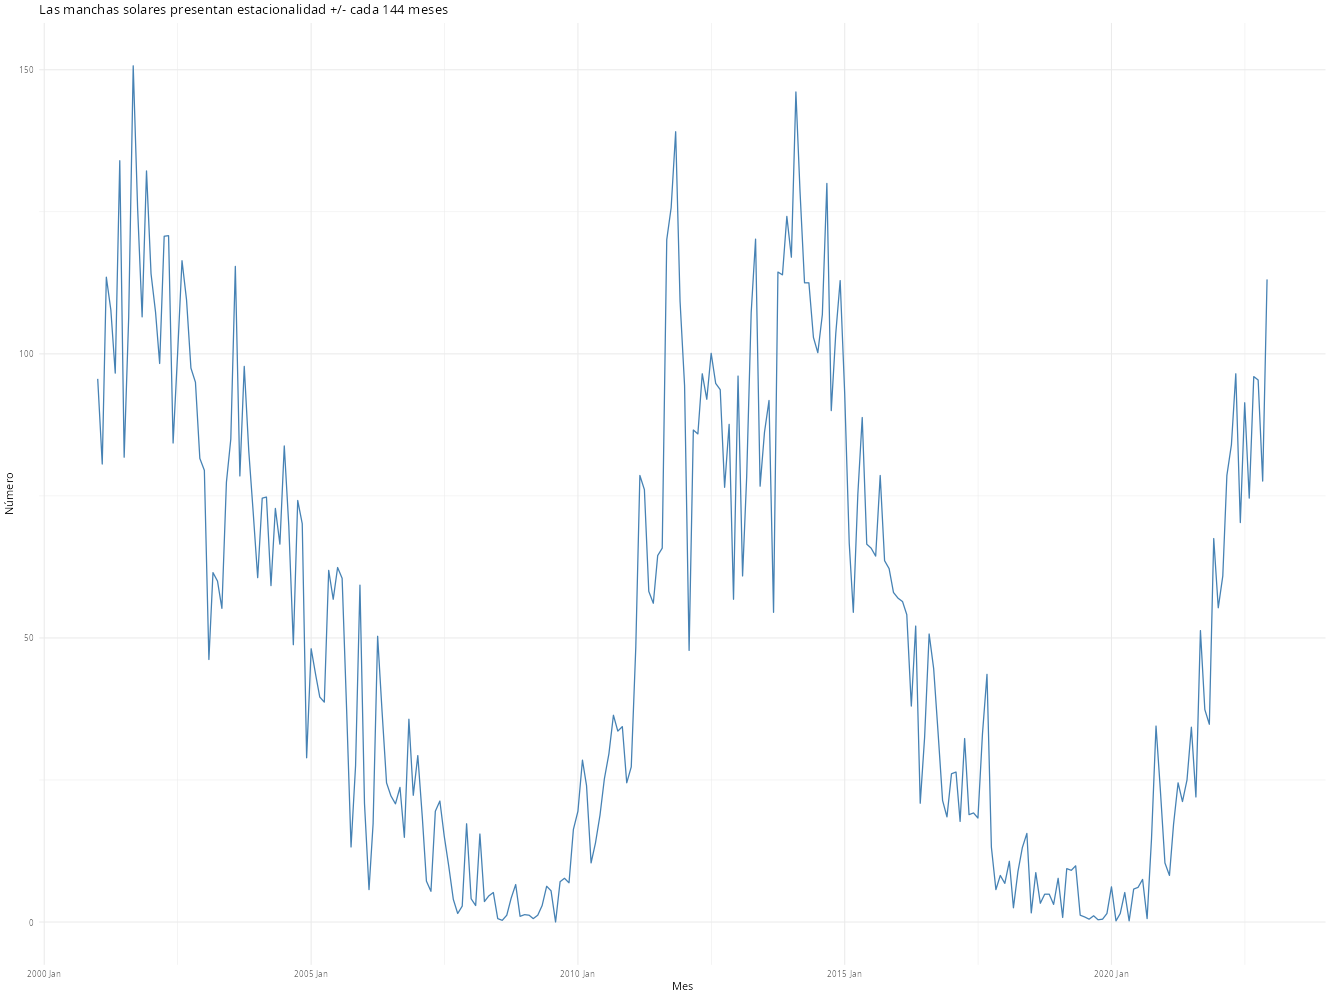

In [19]:
# Las manchas solares presentan estacionalidad +/- cada 144 meses
serie_sunspot |>
  filter(fecha >= yearmonth("2001 Jan")) |>
  autoplot(average, colour = "steelblue", linewidth = 0.6) +
  labs(
    title = "Las manchas solares presentan estacionalidad +/- cada 144 meses",
    x = "Mes", y = "Número"
  ) +
  theme_minimal()

In [29]:
# Regresión armónica dinámica con términos de Fourier
# period = 140: ciclos estacionales de largo plazo
# K = 2: número de pares de términos de Fourier (mayor K = mayor ajuste)
modelo_armonico <- serie_sunspot |>
  model(
    armonico = ARIMA(average ~ fourier(period = 140, K = 2) + PDQ(0, 0, 0) + pdq(0, 0, 0))
  )

report(modelo_armonico)

Series: average 
Model: LM w/ ARIMA(0,0,0) errors 

Coefficients:
      fourier(period = 140, K = 2)C1_140  fourier(period = 140, K = 2)S1_140  fourier(period = 140, K = 2)C2_140
                                 -2.2651                            -15.6114                              3.2873
s.e.                              1.0508                              1.0503                              1.0506
      fourier(period = 140, K = 2)S2_140  intercept
                                  0.9137    52.4403
s.e.                              1.0504     0.7429

sigma^2 estimated as 1817:  log likelihood=-17000.68
AIC=34013.36   AICc=34013.38   BIC=34049.94


Plot variable not specified, automatically selected `.vars = .fitted`


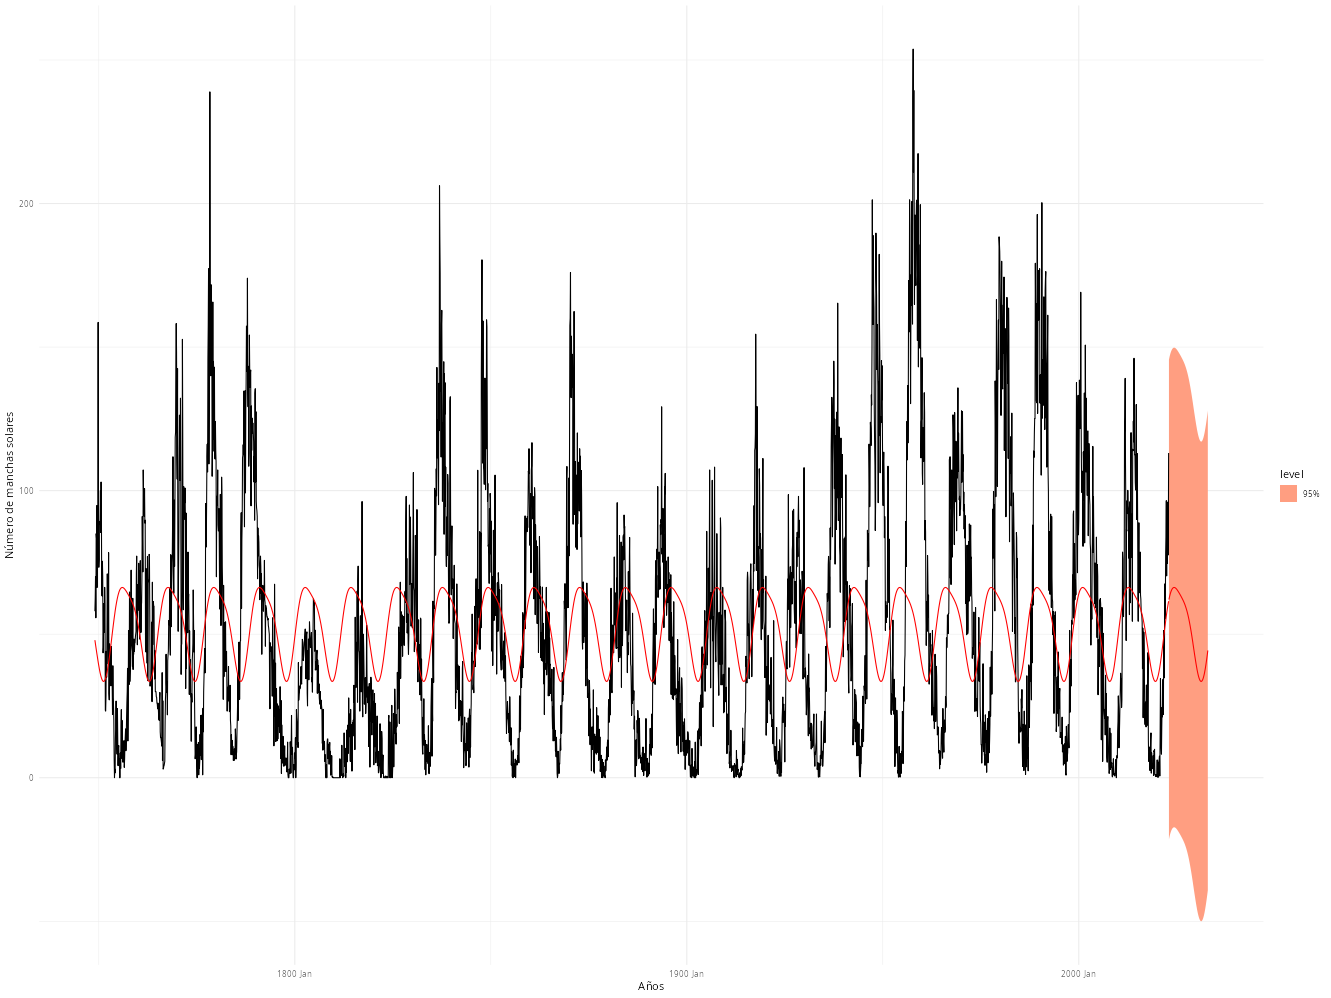

In [30]:
# Pronóstico de los próximos 10 años = 12 meses * 10 = 120 períodos
t_pronostico <- 120

pronostico_armonico <- modelo_armonico |>
  forecast(h = t_pronostico)

# Gráfico de resultados del pronóstico con intervalo de confianza del 95%
pronostico_armonico |>
  autoplot(serie_sunspot, colour = "red", linetype = "dashed", level = 95) +
  autolayer(fitted(modelo_armonico), colour = "red") +
  labs(
    x = "Años", y = "Número de manchas solares"
  ) +
  theme_minimal()